Accelerating Astrodendro with numba
===================================
[numba](https://numba.pydata.org) can be used to accelerate explicit loops in python.
Let's see how well this works for astrodendro.

In [1]:
from numba import njit
import numpy as np
from dendro.utils import get_1d_data
import matplotlib.pyplot as plt
from time import perf_counter_ns
from astrodendro import Dendrogram

n = 1024
n_timings = 100
n_init = 20

x, data = get_1d_data(n)
x = np.array(x)
data = np.array(data)

/var/folders/zl/pxyz2x2x591c234cc02rcn_40000gn/T/ipykernel_51109/3229643681.py:13: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x)
/var/folders/zl/pxyz2x2x591c234cc02rcn_40000gn/T/ipykernel_51109/3229643681.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)


First, we do a simple naive implementation of the dendrogram computation in numpy only

In [2]:

def dendrogram(data):
    # Create empty boolean array to put features in as masks
    structures = np.zeros((np.prod(data.shape), *data.shape), dtype=bool)
    num_structures = 0

    # sort data by value
    idx = np.argsort(data)[::-1]

    # create first leaf as largest value
    structures[0][idx[0]] = True
    num_structures += 1

    # loop through all data and assign to leaves
    for i in idx[1:]:

        # determine how many structures are adjacent
        adjacent = []
        for j in range(num_structures):
            if i+1 < data.shape[0] and structures[j][i+1]:
                adjacent.append(j)
            elif i-1 >= 0 and structures[j][i-1]:
                adjacent.append(j)

        # determine what do to with the current value
        if len(adjacent) == 0:  # no adjacent structures: start a new one
            structures[num_structures][i] = True
            num_structures += 1

        elif len(adjacent) == 1:  # one adjacent structure: merge this value into this structure
            structures[adjacent[0]][i] = True

        elif len(adjacent) == 2:  # two adjacent structures: create new parent structure
            for k in adjacent:
                structures[num_structures] = np.logical_or(structures[num_structures], structures[k])
            structures[num_structures][i] = True
            num_structures += 1
        else:  # more than two adjacent structure: merge into parent structure
            structures[adjacent[-1]][i] = True

    return structures[:num_structures, ...]

Now let's plot the dendrograms and see if they match. Don't mind the colors, I still need to fix the IO...

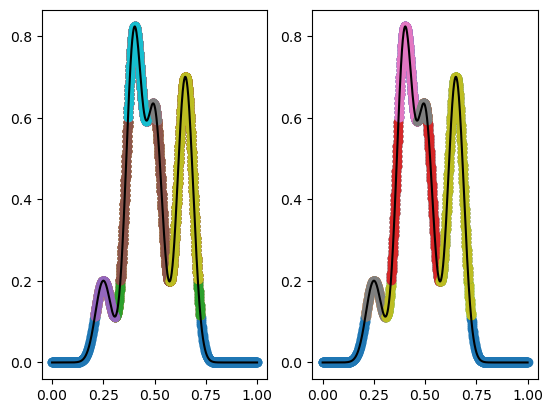

In [3]:
def plot_dendrogram(ax, x, data, structures):
    ax.plot(x, data, color='black')
    for s in structures[::-1]:
        ax.scatter(x[s], data[s])

def plot_astrodendro_leaves(ax, leaves, level=0):
    if level == 0:
        ax.plot(x, data, color='black')
    for leaf in leaves:
        ax.scatter(x[leaf._indices], data[leaf._indices])
        plot_astrodendro_leaves(ax=ax, leaves=leaf._children, level=level + 1)

fig, axs = plt.subplots(1, 2)

d = dendrogram(data)
plot_dendrogram(axs[0], x, data, d)
d_astro = Dendrogram.compute(data)
plot_astrodendro_leaves(axs[1], d_astro)

They don't match identically, but they are close enough, I would say...

Now, let's make this naive implementation faster by simply wrapping with a numba decorator

In [4]:
@njit
def numba_dendrogram(data):
    size = 1
    for s in data.shape:
        size *= s
    structures = np.zeros((size, *data.shape), dtype=np.bool_)
    
    num_structures = 0

    idx = np.argsort(data)[::-1]

    structures[0][idx[0]] = True
    num_structures += 1

    for i in idx[1:]:

        # determine how many structures are adjacent
        adjacent = []
        for j in range(num_structures):
            if i+1 < data.shape[0] and structures[j][i+1]:
                adjacent.append(j)
            elif i-1 >= 0 and structures[j][i-1]:
                adjacent.append(j)

        # determine what do to with the current value
        if len(adjacent) == 0:  # no adjacent structures: start a new one
            structures[num_structures][i] = True
            num_structures += 1

        elif len(adjacent) == 1:  # one adjacent structure: merge this value into this structure
            structures[adjacent[0]][i] = True

        elif len(adjacent) == 2:  # two adjacent structures: create new parent structure
            for k in adjacent:
                structures[num_structures] = np.logical_or(structures[num_structures], structures[k])
            structures[num_structures][i] = True
            num_structures += 1
        else:  # more than two adjacent structure: merge into parent structure
            structures[adjacent[-1]][i] = True

    return structures[:num_structures, ...]

Let's make sure that the naive implementations in numpy and numba give the same results

In [5]:
d = dendrogram(data)
numba_d = numba_dendrogram(data)
assert np.allclose(d, numba_d)

Ok, now let's time this stuff!

In [6]:

timings_numpy = []
timings_numba = []
timings_astro = []
for i in range(n_timings):
    t0 = perf_counter_ns()
    _d = dendrogram(data)
    t1 = perf_counter_ns()
    _d_numba = numba_dendrogram(data)
    t2 = perf_counter_ns()
    d_astro = Dendrogram.compute(data)
    t3 = perf_counter_ns()

    timings_numpy.append(t1 - t0)
    timings_numba.append(t2 - t1)
    timings_astro.append(t3 - t2)

avg_numpy = np.mean(timings_numpy[n_init:])
avg_numba = np.mean(timings_numba[n_init:])
avg_astro = np.mean(timings_astro[n_init:])
print(f'Timings full dendrogram: astrodendro: {avg_astro:.2e}ns numpy: {avg_numpy:.2e}ns numba: {avg_numba:.2e}ns -> speedup wrt to numpy {avg_numpy / avg_numba:.2f} speedup wrt to astrodendro: {avg_astro / avg_numba:.2f}')

Timings full dendrogram: astrodendro: 4.63e+06ns numpy: 4.00e+06ns numba: 1.39e+05ns -> speedup wrt to numpy 28.72 speedup wrt to astrodendro: 33.24


Clearly, the lesson is to not explicitly loop through numpy arrays, unless accelerated by numba..

On the other hand, we typically call the dendrogram only once, then we see the jit cost and get:


In [7]:
print(f'Timings full dendrogram with jit compilation: astrodendro: {timings_astro[0]:.2e}ns numpy: {timings_numpy[0]:.2e}ns numba: {timings_numba[0]:.2e}ns -> speedup wrt to numpy {timings_numpy[0] / timings_numba[0]:.2f} speedup wrt to astrodendro: {timings_astro[0] / timings_numba[0]:.2f}')

Timings full dendrogram with jit compilation: astrodendro: 4.93e+06ns numpy: 4.28e+06ns numba: 2.49e+05ns -> speedup wrt to numpy 17.20 speedup wrt to astrodendro: 19.84


Well, that's still respectable speedup, actually.

In [8]:
if __name__ == '__main__':
    plt.show()